# Exploratory Data Analysis on Netflix Shows and Movies Dataset


Netflix is one of the most popular media and video streaming platforms. They have over 8000 movies or tv shows available on their platform, as of mid-2021, they have over 200M Subscribers globally. This tabular dataset consists of listings of all the movies and tv shows available on Netflix, along with details such as - cast, directors, ratings, release year, duration, etc.

The dataset consists of a list of all the TV shows/movies available on Netflix:

* Show_id: Unique ID for every Movie / Tv Show
* Type: Identifier - A Movie or TV Show
* Title: Title of the Movie / Tv Show
* Director: Director of the Movie
* Cast: Actors involved in the movie/show
* Country: Country where the movie/show was produced
* Date_added: Date it was added on Netflix
* Release_year: Actual Release year of the movie/show
* Rating: TV Rating of the movie/show
* Duration: Total Duration - in minutes or number of seasons
* Listed_in: Genre
* Description: The summary description

# Importing Libraries and Loading the data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
netflix = pd.read_csv("netflix_titles.csv")

In [4]:
#creating copy of the dataset
df = netflix.copy()

# Basic Observations

In [5]:
#top 5 rows of the dataset
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
#bottom 5 rows of the dataset
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [7]:
df.shape

(8807, 12)

Total 8807 rows and 12 columns present in our dataset

In [8]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

These are the column present in the dataset

In [9]:
#informational summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [10]:
#descriptive summary
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [11]:
##total unique counts
df.nunique()

show_id         8807
type               2
title           8807
director        4528
cast            7692
country          748
date_added      1767
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64

show_id column has all unique values, Title column has all unique values    i.e. total 8807 which equals to total rows in the dataset.
Hence It can be concluded that ,
Total 8807 movies/TV shows data is provided in the dataset.

# Data Cleaning

Total null values present in each column of the dataset :

In [12]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

3 missing value in duration, 4 missing values in rating,10 missing values in date_added, 831 missing values in country, 825 missing values in cast, 2634 missing values in director column

In [13]:
df[df['duration'].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


by mistake duration column data entered in the rating column

In [14]:
ind = df[df['duration'].isna()].index

In [15]:
df.loc[ind] = df.loc[ind].fillna(method='ffill',axis=1)

In [16]:
df.loc[ind,'rating']='Not Available'

null values present in rating column

In [17]:
df[df['rating'].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,"Oprah Winfrey, Ava DuVernay",NaN,"January 26, 2017",2017,NaN,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...
6827,s6828,TV Show,Gargantia on the Verdurous Planet,NaN,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,"December 1, 2016",2013,NaN,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel..."
7312,s7313,TV Show,Little Lunch,NaN,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,"February 1, 2018",2015,NaN,1 Season,"Kids' TV, TV Comedies","Adopting a child's perspective, this show take..."
7537,s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,"March 1, 2017",2015,NaN,115 min,Dramas,"Amid the chaos and horror of World War II, a c..."


In [18]:
ind1 = df[df['rating'].isna()].index

In [19]:
df.loc[ind1,'rating'] = "Not Available"

In [20]:
#remove spaces,fix string
df['date_added'] = df['date_added'].astype(str).str.strip()

In [21]:
#remove invalid values
df['date_added'] = df['date_added'].replace(['Unknown','N/A',''],None)

In [22]:
#changing the data type of date_added column
df['date_added'] = pd.to_datetime(df['date_added'],errors='coerce')
df.dropna(subset=['date_added'],inplace=True)

In [23]:
#replacing null values with unknown
df['country'] = df['country'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Unknown")
df['director'] = df['director'].fillna("Unknown")

In [24]:
df.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

now there is no null values in the dataset

In [25]:
df['release_year'].unique()

array([2020, 2021, 1993, 2018, 1996, 1998, 1997, 2010, 2013, 2017, 1975,
       1978, 1983, 1987, 2012, 2001, 2014, 2002, 2003, 2004, 2011, 2008,
       2009, 2007, 2005, 2006, 1994, 2015, 2019, 2016, 1982, 1989, 1990,
       1991, 1999, 1986, 1992, 1984, 1980, 1961, 2000, 1995, 1985, 1976,
       1959, 1988, 1981, 1972, 1964, 1945, 1954, 1979, 1958, 1956, 1963,
       1970, 1973, 1925, 1974, 1960, 1966, 1971, 1962, 1969, 1977, 1967,
       1968, 1965, 1946, 1942, 1955, 1944, 1947, 1943], dtype=object)

In [26]:
#changing the data type
df['release_year']=pd.to_numeric(df['release_year'],errors='coerce')

In [27]:
df.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8797 non-null   object        
 1   type          8797 non-null   object        
 2   title         8797 non-null   object        
 3   director      8797 non-null   object        
 4   cast          8797 non-null   object        
 5   country       8797 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8797 non-null   int64         
 8   rating        8797 non-null   object        
 9   duration      8797 non-null   object        
 10  listed_in     8797 non-null   object        
 11  description   8797 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 893.4+ KB


adding new column year_added,month_added by exacting year and month from date_added column

In [29]:
#creating a new feature
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [30]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9


In listed_in column multiple group genre are present

In [31]:
df['listed_in'] = df['listed_in'].str.split(',')
df = df.explode('listed_in').reset_index(drop=True)
df['listed_in'] = df['listed_in'].str.strip()

In [32]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",2021,9


In [33]:
#rename the column listed-in to genre
df = df.rename(columns={'listed_in':'genre'})
df['genre'] = df['genre'].astype('category')

Country column has multiple group country values 

In [34]:
df['country'] = df['country'].str.split(',')
df = df.explode('country')
df['country'] = df['country'].str.strip()

In [35]:
df['country'].nunique()

124

In [36]:
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",2021,9
2,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t...",2021,9
3,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t...",2021,9
4,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,Crime TV Shows,To protect his family from a powerful drug lor...,2021,9
5,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,International TV Shows,To protect his family from a powerful drug lor...,2021,9
6,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,TV Action & Adventure,To protect his family from a powerful drug lor...,2021,9
7,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,Docuseries,"Feuds, flirtations and toilet talk go down amo...",2021,9
8,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,Reality TV,"Feuds, flirtations and toilet talk go down amo...",2021,9
9,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,In a city of coaching centers known to train I...,2021,9


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23744 entries, 0 to 19302
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       23744 non-null  object        
 1   type          23744 non-null  object        
 2   title         23744 non-null  object        
 3   director      23744 non-null  object        
 4   cast          23744 non-null  object        
 5   country       23744 non-null  object        
 6   date_added    23744 non-null  datetime64[ns]
 7   release_year  23744 non-null  int64         
 8   rating        23744 non-null  object        
 9   duration      23744 non-null  object        
 10  genre         23744 non-null  category      
 11  description   23744 non-null  object        
 12  year_added    23744 non-null  int32         
 13  month_added   23744 non-null  int32         
dtypes: category(1), datetime64[ns](1), int32(2), int64(1), object(9)
memory usage: 2.4+ MB


In [38]:
#save the cleaned data
df.to_csv("clean_netflix_shows_movies_dataset.csv",index=False)

# Exploratory Data Analysis

In [39]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",2021,9


In [40]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
genre           0
description     0
year_added      0
month_added     0
dtype: int64

In [41]:
df.describe()

,date_added,release_year,year_added,month_added
count,23744,23744.000000,23744.000000,23744.000000
mean,2019-05-18 12:34:48.679245056,2013.893615,2018.878369,6.621336
min,2008-01-01 00:00:00,1925.000000,2008.000000,1.000000
25%,2018-04-13 00:00:00,2013.000000,2018.000000,4.000000
50%,2019-07-07 00:00:00,2017.000000,2019.000000,7.000000
75%,2020-08-10 00:00:00,2019.000000,2020.000000,10.000000
max,2021-09-25 00:00:00,2021.000000,2021.000000,12.000000
std,NaN,8.898368,1.547392,3.448726


In [42]:
#movies vs tv shows
df['type'].value_counts()

type
Movie      16883
TV Show     6861
Name: count, dtype: int64

In [43]:
#content growth over time
df['year_added'].value_counts().sort_index()
year_type_trend = df.groupby(['year_added','type']).size().unstack().fillna(0).astype(int)
year_type_trend['Total'] = year_type_trend.sum(axis=1)
print(year_type_trend)

type        Movie  TV Show  Total
year_added                       
2008            3        1      4
2009            3        0      3
2010            2        0      2
2011           29        0     29
2012            5        0      5
2013           10       19     29
2014           38       17     55
2015          135       68    203
2016          620      490   1110
2017         2320      917   3237
2018         3488     1056   4544
2019         3890     1516   5406
2020         3607     1547   5154
2021         2733     1230   3963


In [44]:
# top directors
df['director'].value_counts().head()

director
Unknown                6547
Youssef Chahine          46
Cathy Garcia-Molina      37
Martin Scorsese          36
Lars von Trier           33
Name: count, dtype: int64

In [45]:
#top 10 most content creating contries
df['country'].value_counts().head(10)

country
United States     6768
India             2804
United Kingdom    1780
Unknown           1721
France             916
Canada             877
Japan              731
South Korea        632
Spain              591
Germany            511
Name: count, dtype: int64

In [46]:
#yearly maximum content release from which country and its count
yearly_country_count = df.groupby(['release_year','country']).size()
yearly_top_country = yearly_country_count.groupby(level=0).idxmax()
yearly_top_value = yearly_country_count.groupby(level=0).max()
yearly_top_country_content = pd.DataFrame({
    'Top Country' : yearly_top_country.apply(lambda x:x[1]),
    'Content_count' : yearly_top_value
})
print(yearly_top_country_content)

                Top Country  Content_count
release_year                              
1925                Unknown              1
1942          United States              4
1943          United States              4
1944          United States              6
1945          United States              7
...                     ...            ...
2017          United States            747
2018          United States            859
2019          United States            792
2020          United States            692
2021                Unknown            457

[74 rows x 2 columns]


In [47]:
#rating distribution
rating_distribution = df['rating'].value_counts()
print(rating_distribution)

rating
TV-MA            8655
TV-14            5799
R                2499
TV-PG            2205
PG-13            1584
PG                904
TV-Y7             673
TV-Y              521
TV-G              500
NR                235
G                 119
TV-Y7-FV           17
NC-17              13
UR                 11
Not Available       9
Name: count, dtype: int64


In [48]:
#genre analysis
genre_distribution = df['genre'].value_counts()
print(genre_distribution)

genre
International Movies            3513
Dramas                          3202
Comedies                        1981
International TV Shows          1464
Action & Adventure              1182
Documentaries                   1118
Independent Movies              1040
TV Dramas                        851
Children & Family Movies         845
Thrillers                        806
Romantic Movies                  722
TV Comedies                      623
Kids' TV                         594
Crime TV Shows                   540
Horror Movies                    458
Docuseries                       435
Music & Musicals                 429
Romantic TV Shows                384
Sci-Fi & Fantasy                 380
Stand-Up Comedy                  344
British TV Shows                 305
Reality TV                       270
Sports Movies                    265
TV Action & Adventure            203
Spanish-Language TV Shows        201
Anime Series                     191
Korean TV Shows                 

In [49]:
#genre-wise rating distribution
genre_rating = df.groupby(['genre','rating']).size().unstack()
print(genre_rating)

rating                         G  NC-17  NR  Not Available   PG  PG-13    R  \
genre                                                                         
Action & Adventure             1      0  11              0   41    251  366   
Anime Features                 0      0   0              0    6      5    0   
Anime Series                   0      0   0              1    0      0    0   
British TV Shows               0      0   2              0    0      0    0   
Children & Family Movies      50      0   0              0  305     18    0   
Classic & Cult TV              0      0   0              0    0      0    0   
Classic Movies                11      0   4              0   21     15   46   
Comedies                      23      2  15              0  228    215  233   
Crime TV Shows                 0      0   1              0    0      0    0   
Cult Movies                    0      0   3              0    5     16   55   
Documentaries                  9      0  35         

In [50]:
# top 5 movies duration analysis
movies = df[df['type'] == "Movie"].copy()
movies['duration'] = movies['duration'].str.replace('min','').astype(int)
movies = movies.drop_duplicates(subset=['title','duration'])
movies[['title','duration']].head(5)


,title,duration
0,Dick Johnson Is Dead,90
15,My Little Pony: A New Generation,91
16,Sankofa,125
21,The Starling,104
29,Je Suis Karl,127


In [51]:
#yearly total content release
year_content=df['year_added'].value_counts().sort_index()
print(year_content)

year_added
2008       4
2009       3
2010       2
2011      29
2012       5
2013      29
2014      55
2015     203
2016    1110
2017    3237
2018    4544
2019    5406
2020    5154
2021    3963
Name: count, dtype: int64


In [52]:
#monthly total content release
month_content = df['month_added'].value_counts().sort_index()
print(month_content)

month_added
1     2095
2     1540
3     1965
4     2084
5     1654
6     1970
7     2246
8     2027
9     2073
10    2056
11    1842
12    2192
Name: count, dtype: int64


# Visualization

Movies vs TV Shows

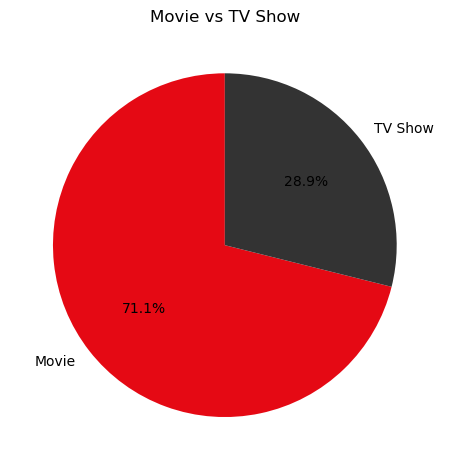

In [53]:
types = df['type'].value_counts()
colors = ['#E50914','#333333']
plt.pie(types.values,colors=colors,labels=types.index,autopct='%1.1f%%',startangle=90)
plt.title("Movie vs TV Show")
plt.tight_layout()
plt.show()

Content Growth Over Time

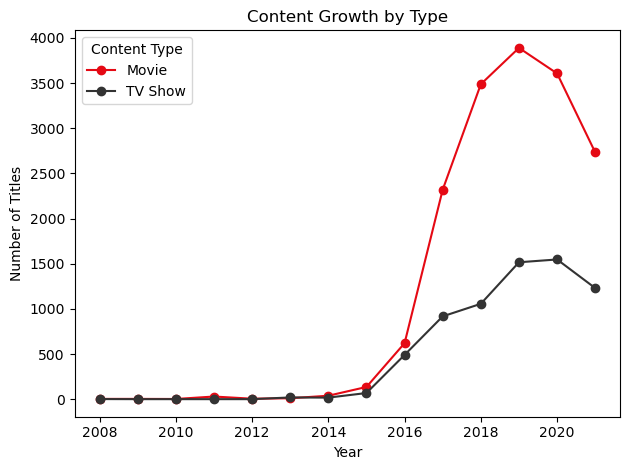

In [54]:
year_content = df.groupby(['year_added','type']).size().unstack().fillna(0)
year_content.plot(marker='o',color= ['#E50914','#333333'] )
plt.title("Content Growth by Type")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.legend(title='Content Type')
plt.tight_layout()
plt.show()

Top Directors

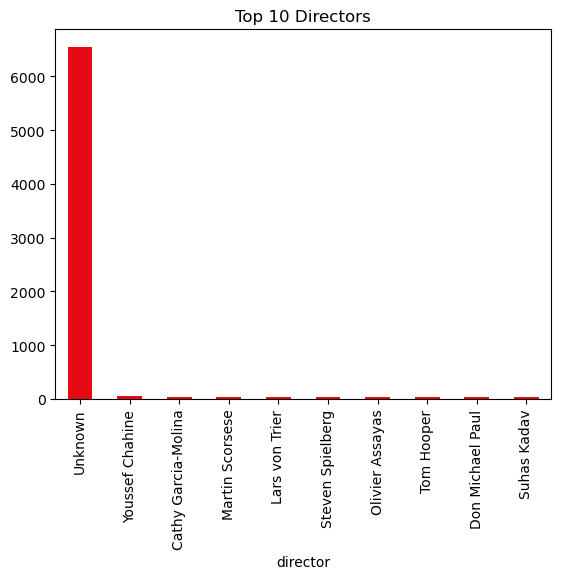

In [55]:
df['director'].value_counts().head(10).plot(kind='bar',color = '#E50914')
plt.title('Top 10 Directors')
plt.show()


Most Content Creating Country

<Axes: ylabel='country'>

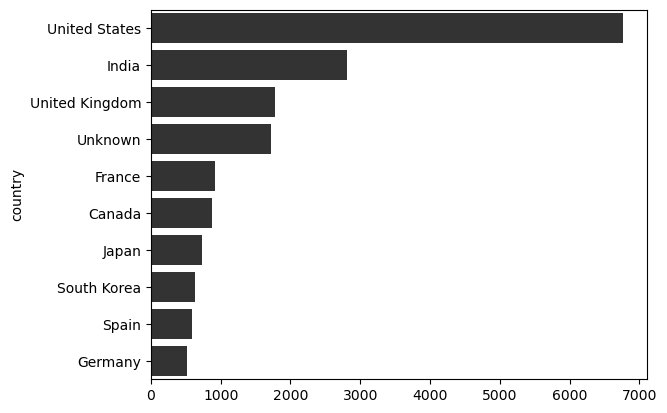

In [56]:
top_country = df['country'].value_counts().head(10)
sns.barplot(x=top_country.values,y=top_country.index,color='#333333')

Number of Contents Release By Year and Month

In [57]:
year_content = df['year_added'].value_counts().sort_index()
month_content = df['month_added'].value_counts().sort_index()

Text(0.5, 1.0, 'Monthly Content Distribution')

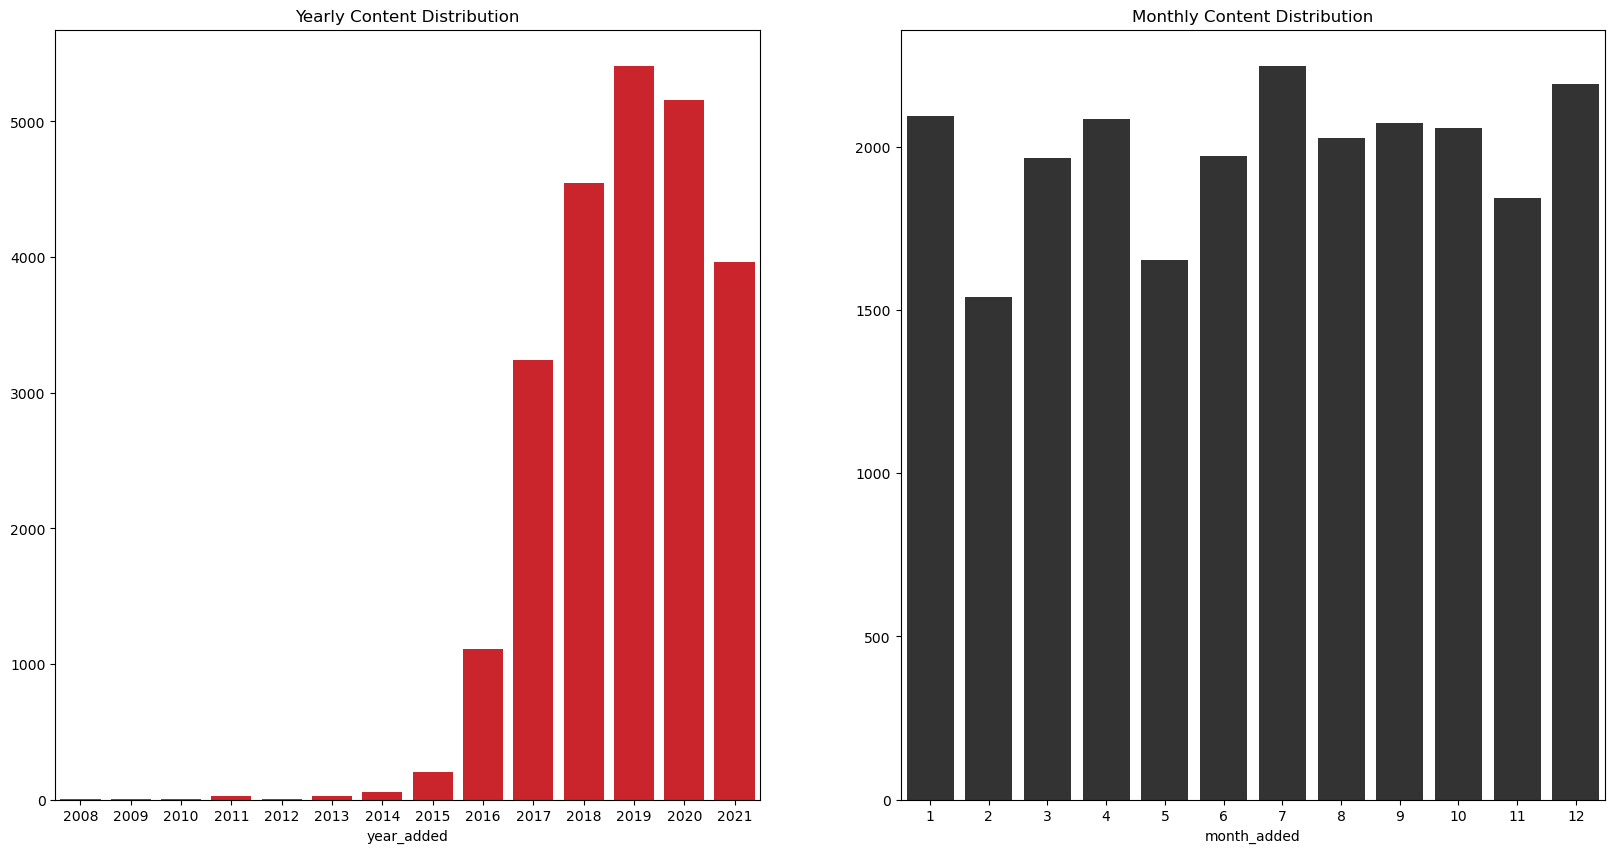

In [58]:
fig,axes = plt.subplots(1,2,figsize=(20,10))
sns.barplot(x=year_content.index,y=year_content.values,color='#E50914',ax=axes[0])
axes[0].set_title('Yearly Content Distribution')
sns.barplot(x=month_content.index,y=month_content.values,color='#333333',ax=axes[1])
axes[1].set_title('Monthly Content Distribution')

Top 10 Genre

In [59]:
df['genre'].value_counts()


genre
International Movies            3513
Dramas                          3202
Comedies                        1981
International TV Shows          1464
Action & Adventure              1182
Documentaries                   1118
Independent Movies              1040
TV Dramas                        851
Children & Family Movies         845
Thrillers                        806
Romantic Movies                  722
TV Comedies                      623
Kids' TV                         594
Crime TV Shows                   540
Horror Movies                    458
Docuseries                       435
Music & Musicals                 429
Romantic TV Shows                384
Sci-Fi & Fantasy                 380
Stand-Up Comedy                  344
British TV Shows                 305
Reality TV                       270
Sports Movies                    265
TV Action & Adventure            203
Spanish-Language TV Shows        201
Anime Series                     191
Korean TV Shows                 

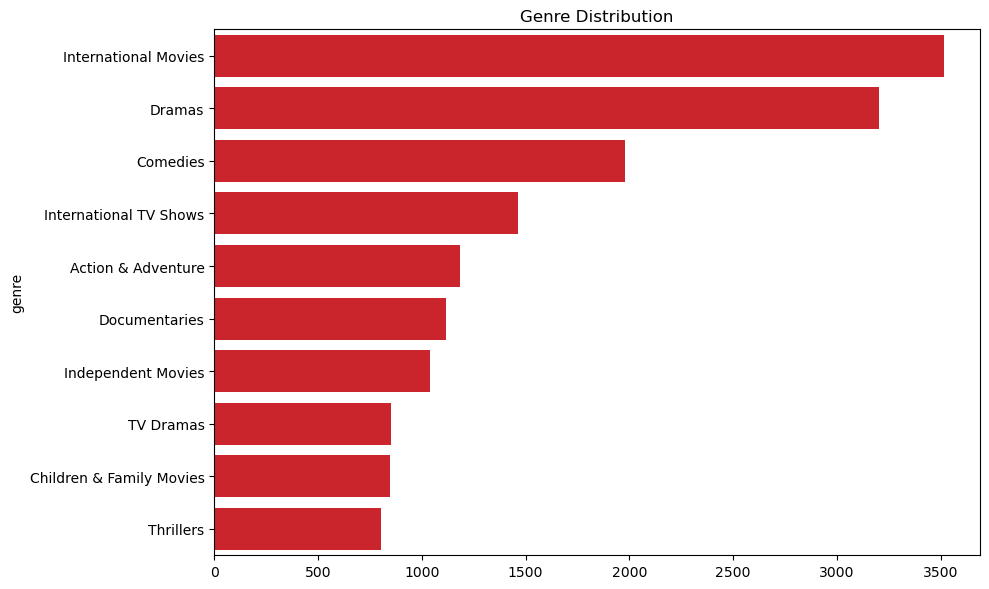

In [60]:
plt.figure(figsize=(10,6))
top_10_genre = df['genre'].value_counts().head(10)
sns.barplot(x=top_10_genre.values,y=top_10_genre.index,order=top_10_genre.index,color='#E50914')
plt.title('Genre Distribution')
plt.tight_layout()
plt.show()

Rating Distribution

<Axes: ylabel='rating'>

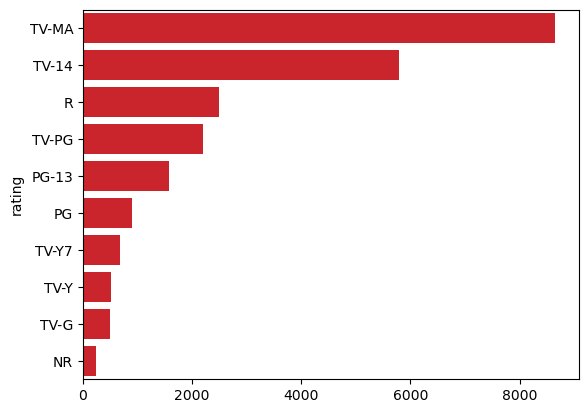

In [61]:
top_10_rating = df['rating'].value_counts().head(10)
sns.barplot(x=top_10_rating.values,y=top_10_rating.index,color='#E50914')

# Insights

* 69.7% content on Netflix is Movies and 30.3% content is TV shows.

* Netflix content peaked in 2019 and then declined

* International Movies and Dramas are the two top genres on Netflix

* Maximum content of Netflix produced from United States.

* TV-MA is the most common rating.


* Maximum Content of Netflix released in July. 